In [1]:
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from pathlib import Path
from PIL import Image
import numpy as np


In [2]:

DATA_DIR = "data/train"

print("Path tồn tại:", os.path.exists(DATA_DIR))
print("Absolute path:", os.path.abspath(DATA_DIR))

for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        print(cls, "->", len(os.listdir(cls_path)), "ảnh")


Path tồn tại: True
Absolute path: d:\NCKH\data\train
close -> 246 ảnh
open -> 242 ảnh


In [3]:

DATA_DIR = Path("data/train")

ext_counter = Counter()

for img_path in DATA_DIR.rglob("*"):
    if img_path.is_file():
        ext_counter[img_path.suffix.lower()] += 1

print("Các đuôi file trong dataset:")
for ext, count in ext_counter.items():
    print(f"{ext}: {count}")


Các đuôi file trong dataset:
.png: 488


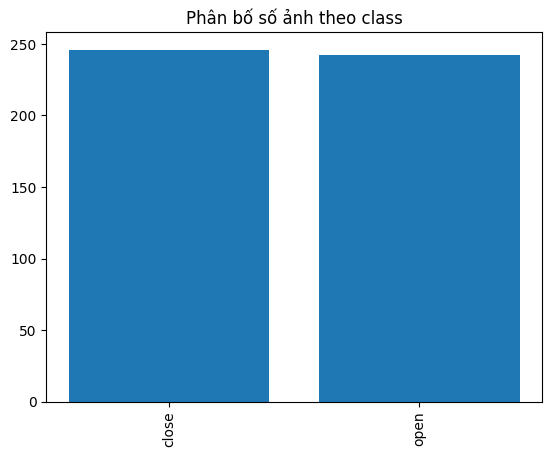

In [4]:

class_counts = {}
for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Phân bố số ảnh theo class")
plt.show()


In [5]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder("data/test", transform=transform)

print("Số ảnh:", len(dataset))
print("Số class:", len(dataset.classes))
print("Classes:", dataset.classes[:5])


Số ảnh: 66
Số class: 2
Classes: ['close', 'open']


In [6]:


DATA_DIR = Path("data/")

sizes = []

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        with Image.open(img_path) as img:
            sizes.append(img.size)  # (W, H)

sizes = np.array(sizes)

print("Min size (W, H):", sizes.min(axis=0))
print("Max size (W, H):", sizes.max(axis=0))
print("Mean size (W, H):", sizes.mean(axis=0))


Min size (W, H): [ 47 104]
Max size (W, H): [1574  831]
Mean size (W, H): [411.78880866 360.04512635]


In [7]:

channel_counter = Counter()

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        with Image.open(img_path) as img:
            channel_counter[len(img.getbands())] += 1

print("Phân bố số kênh màu:")
print(channel_counter)


Phân bố số kênh màu:
Counter({4: 488, 3: 66})
